# Supply Chain Performance Analysis

## Business Problem

A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including order processing, shipping, and final delivery.

However, the company is facing inconsistent delivery performance, where actual delivery times frequently deviate from scheduled timelines. This has resulted in:

- A high percentage of late deliveries  
- Poor customer experience and satisfaction  
- Increased operational costs  
- Unpredictable and unstable profitability  

These inefficiencies indicate potential bottlenecks within the supply chain that need to be identified and addressed.

---

## Desired Outcome

The objective of this project is to analyze the supply chain performance and identify key issues affecting delivery efficiency and profitability.

Specifically, the project aims to:

- Analyze delivery timelines and measure delay patterns  
- Identify bottlenecks in the supply chain (regions, categories, or processes)  
- Quantify the impact of delays on business profit  
- Generate key performance indicators (KPIs) for decision-making  
- Provide actionable insights and recommendations to reduce delays and improve overall efficiency  

Ultimately, this analysis will help the business optimize operations, enhance customer satisfaction, and improve profitability.

In [1]:
# Importing libraries 
import pandas as pd          # Used for data manipulation and analysis (DataFrames)
import numpy as np           # Used for numerical operations and calculations
import matplotlib.pyplot as plt   # Basic plotting library for charts
import seaborn as sns             # Advanced visualization (better looking graphs)
import matplotlib.ticker as ticker   # Used for customizing axis ticks
import matplotlib.cm as cm           # Used for color maps in plots
from warnings import filterwarnings  ## Ignore warnings to keep output clean
filterwarnings('ignore')

In [2]:
# Set professional visualization theme and colors

# Use a clean and professional plot style
plt.style.use('seaborn-v0_8-whitegrid')

# Set default color palette for seaborn charts
sns.set_palette("viridis")

# Generate a range of colors from viridis colormap
viridis_colors = cm.viridis(np.linspace(0, 1, 5))

# Assign custom colors for use in plots
primary_color = viridis_colors[0]     
secondary_color = viridis_colors[1]   
accent_color = viridis_colors[2]     
danger_color = "#800000"              
neutral_color = viridis_colors[4]   

# Combine into custom palette
custom_palette = viridis_colors

In [54]:
# Load dataset
df = pd.read_csv("SupplyChainDataset.csv" , encoding='latin-1')  

# Preview first 5 rows
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
#show no of columns in a dataset
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [7]:
# show info - basic information about your dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [8]:
# describe - Gives statistics of numerical columns
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [10]:
# Overview of dataset before  (rows and columns)
print('rows, cols:', df.shape)

# Display all column names
print('\ncolumns:')
print(df.columns.tolist())

# Count duplicate rows
print('\nNum duplicates:', df.duplicated().sum())

# Show missing values sorted (top 20)
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [16]:
# columns to drop based on  dataset
columns_to_drop = [
    'Product Description',      # unnecessary text
    'Product Image',            # image data not needed
    'Customer Email',           # sensitive info
    'Customer Password',        # sensitive info
    'Customer Fname',           # not needed
    'Customer Lname',           # not needed
    'Customer Street',          # detailed address not required
    'Customer Zipcode',         # redundant
    'Order Zipcode',            # redundant
    'Latitude',                 # not needed
    'Longitude',                # not needed
    'Order Item Cardprod Id',   # ID column
    'Order Item Id',            # ID column
    'Order Item Discount',      # not needed
    'Order Item Discount Rate', # not needed
    'Order Item Product Price', # redundant
    'Order Item Quantity',      # not needed
    'Order Item Total',         # redundant
    'Category Id',              # ID
    'Department Id',            # ID
    'Order Id',                 # ID
    'Order Customer Id',        # ID
    'Customer Id',              # ID
    'Product Card Id',          # ID
    'Product Category Id',      # ID
    'Product Status',           # no variation
    'Order City',               # granular location
    'Customer City',            # granular location
    'Order State',              # redundant
    'Customer State',           # redundant
    'Order Country',            # redundant
    'Market'                    # not needed
]

# drop safely
df = df.drop(columns=columns_to_drop, errors='ignore')

In [17]:
# removing canceled orders as they are not useful for delivery analysis
df = df[df['Delivery Status'] != 'Shipping canceled']

# convert date columns into proper datetime format
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

# check dataset again after cleaning
print('rows, cols:', df.shape)

# check missing values again (top 5)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)

Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [19]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [20]:
# check value counts for categorical columns with less unique values
for col in df.columns:
    if df[col].nunique() < 10:   # select columns with less than 10 unique values
        print(f'\n{col} value counts:')
        print(df[col].value_counts())  #Shows how many times each value appears


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [21]:
## Feature Engineering
# calculate order processing time (shipping date - order date)
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days

# calculate delay (actual processing - scheduled days)
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

# create delayed flag (True if delay > 0)
df['Is_Delayed'] = df['Delay'] > 0

# extract month from order date
df['order_month'] = df['order date (DateOrders)'].dt.month

# extract day name from order date
df['order_day'] = df['order date (DateOrders)'].dt.day_name()

# extract hour from order date
df['order_hour'] = df['order date (DateOrders)'].dt.hour

# check summary statistics
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [22]:
# check delayed vs not delayed count
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [23]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [26]:
# create profitability  based on order profit
df['Profitability Flag'] = np.where(
    df['Order Profit Per Order'] > 0, 'Profit',   # profit if value > 0
    np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break Even')  # loss if < 0 else break even
)

# check counts of each category
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break Even      1116
Name: count, dtype: int64

In [27]:
df['Profitability Flag'].value_counts(normalize=True)

Profitability Flag
Profit        0.80661
Loss          0.18693
Break Even    0.00646
Name: proportion, dtype: float64

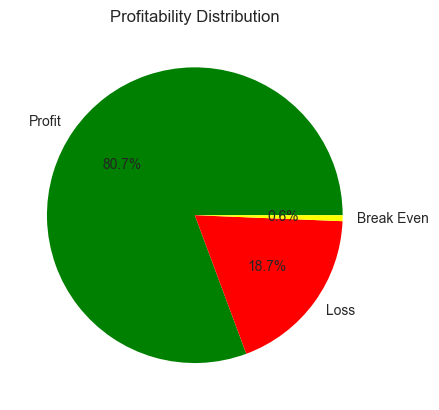

In [32]:
# visualization of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['green', 'red', 'yellow']  ## green=profit, red=loss, yellow=break-even
)

plt.ylabel('')
plt.title('Profitability Distribution')
plt.show()

In [52]:
# save cleaned dataset also
df.to_csv("cleaned_supply_chain_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [34]:
# KPI Calculation
# filter delayed orders
delayed_df = df[df['Delay'] > 0]

# basic KPIs
total_orders = len(df)
late_orders = len(delayed_df)

late_delivery_pct = (late_orders / total_orders) * 100
on_time_pct = 100 - late_delivery_pct

delay_90 = delayed_df['Delay'].quantile(0.90)

total_profit = df[df['Order Profit Per Order'] > 0]['Order Profit Per Order'].sum()
profit_at_risk = df[df['Delay'] > 0]['Order Profit Per Order'].sum()

# print KPIs
print("\n--- Business KPIs ---\n")
print("Total Orders:", total_orders)
print("Late Deliveries:", late_orders)
print("Late Delivery %:", round(late_delivery_pct, 2))
print("On-time Delivery %:", round(on_time_pct, 2))
print("90% Delay (days):", round(delay_90, 2))
print("Total Profit:", round(total_profit, 2))
print("Profit at Risk (Delayed Orders):", round(profit_at_risk, 2))


--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
Late Delivery %: 54.71
On-time Delivery %: 45.29
90% Delay (days): 3.0
Total Profit: 7514813.81
Profit at Risk (Delayed Orders): 2055765.16


## Profitability vs Delivery Time Analysis

In [36]:
# profitability vs delay analysis
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit='mean',
        total_profit='sum',
        order_count='count'
    )
    .reset_index()
)

profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [37]:
# delay distribution (percentage)
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


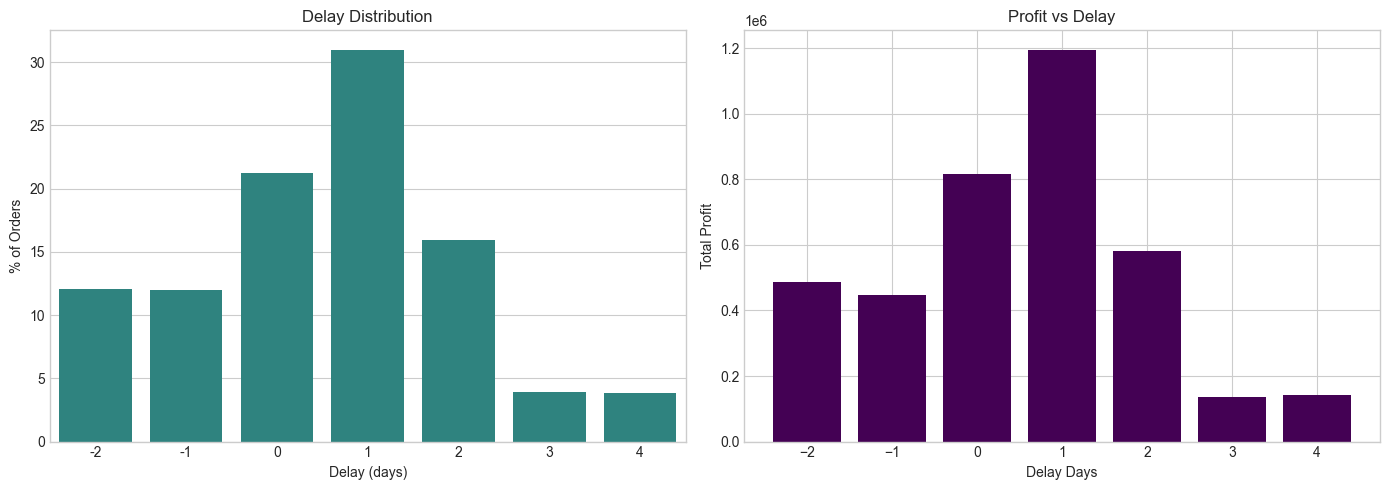

In [39]:
# rename columns
delay_distribution.columns = ['Delay_Days', 'Percentage']

# show tables
print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

# create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Delay Distribution
sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,   # using your accent color
    ax=ax1
)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('% of Orders')

# Profit vs Delay
ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color   # using your primary color
)

ax2.set_title('Profit vs Delay')
ax2.set_xlabel('Delay Days')
ax2.set_ylabel('Total Profit')

plt.tight_layout()
plt.show()

In [40]:
#Bottleneck Detection
# check delay by shipping mode
df.groupby('Shipping Mode')['Delay'].mean().sort_values(ascending=False)

# check delay by region
df.groupby('Order Region')['Delay'].mean().sort_values(ascending=False)

# check delay by category
df.groupby('Category Name')['Delay'].mean().sort_values(ascending=False)

Category Name
Golf Bags & Carts       0.754098
As Seen on  TV!         0.681818
Soccer                  0.669118
Tennis & Racquet        0.649682
Pet Supplies            0.648305
Lacrosse                0.635258
Boxing & MMA            0.629353
Strength Training       0.623853
Trade-In                0.615551
Women's Clothing        0.610143
Crafts                  0.609170
Cameras                 0.606762
Fitness Accessories     0.591216
Golf Gloves             0.590865
Baseball & Softball     0.589786
Consumer Electronics    0.579462
Accessories             0.574543
Sporting Goods          0.571429
Kids' Golf Clubs        0.570225
Video Games             0.557214
Music                   0.556355
Women's Golf Clubs      0.552941
Cleats                  0.552182
Girls' Apparel          0.551451
Children's Clothing     0.549839
Shop By Sport           0.548264
Electronics             0.545966
Garden                  0.545064
Golf Shoes              0.543825
Men's Footwear          0.541

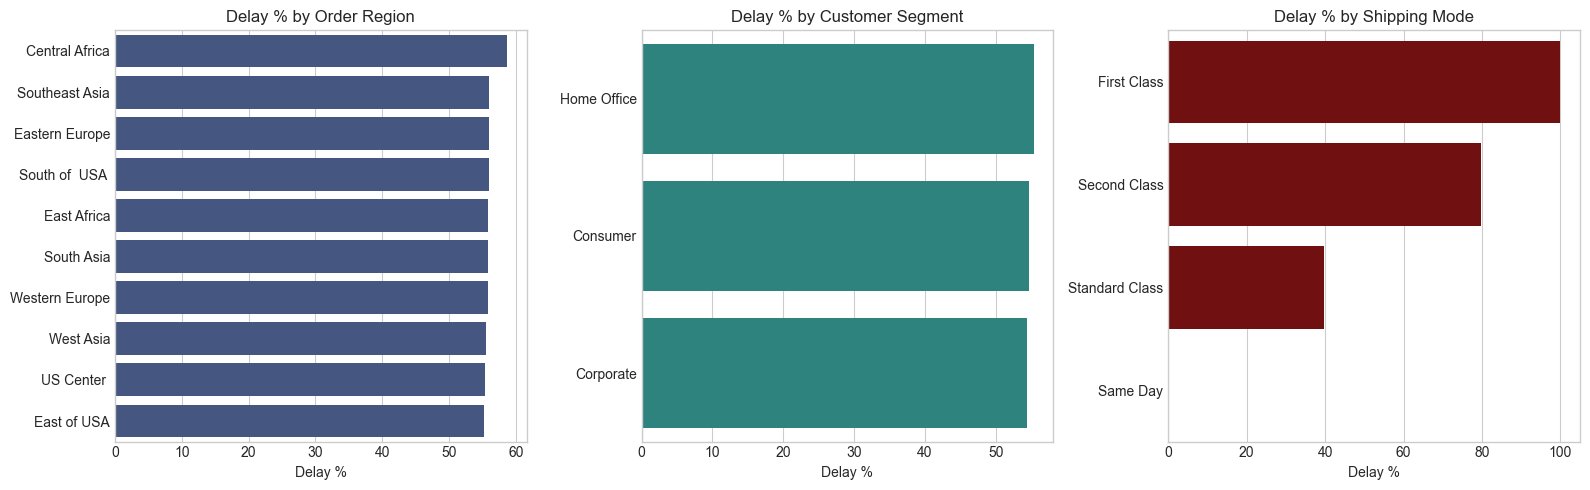

In [44]:
# function to calculate delay %
def compute_delay_pct(category):
    temp = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
    return temp.sort_values('delay_pct', ascending=False).head(10)


# categories to analyze
categories = ['Order Region', 'Customer Segment', 'Shipping Mode']

# pick 3 colors from your palette
colors = [secondary_color, accent_color, danger_color]


# plotting
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, cat, col in zip(axes, categories, colors):
    temp = compute_delay_pct(cat)

    sns.barplot(
        data=temp,
        x='delay_pct',
        y=cat,
        color=col,
        ax=ax
    )

    ax.set_title(f'Delay % by {cat}')
    ax.set_xlabel('Delay %')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


--- Root Cause Analysis ---

Delay by Shipping Mode:
 Shipping Mode
Second Class      1.993167
First Class       1.000000
Same Day          0.000000
Standard Class   -0.006301
Name: Delay, dtype: float64

Delay by Order Region:
 Order Region
Central Africa    0.613243
Central Asia      0.607011
US Center         0.578985
South Asia        0.571294
South of  USA     0.570687
Western Europe    0.568988
Eastern Europe    0.568560
East Africa       0.565974
East of USA       0.555085
West Asia         0.552732
Name: Delay, dtype: float64

Delay by Customer Segment:
 Customer Segment
Home Office    0.556543
Consumer       0.539018
Corporate      0.531031
Name: Delay, dtype: float64


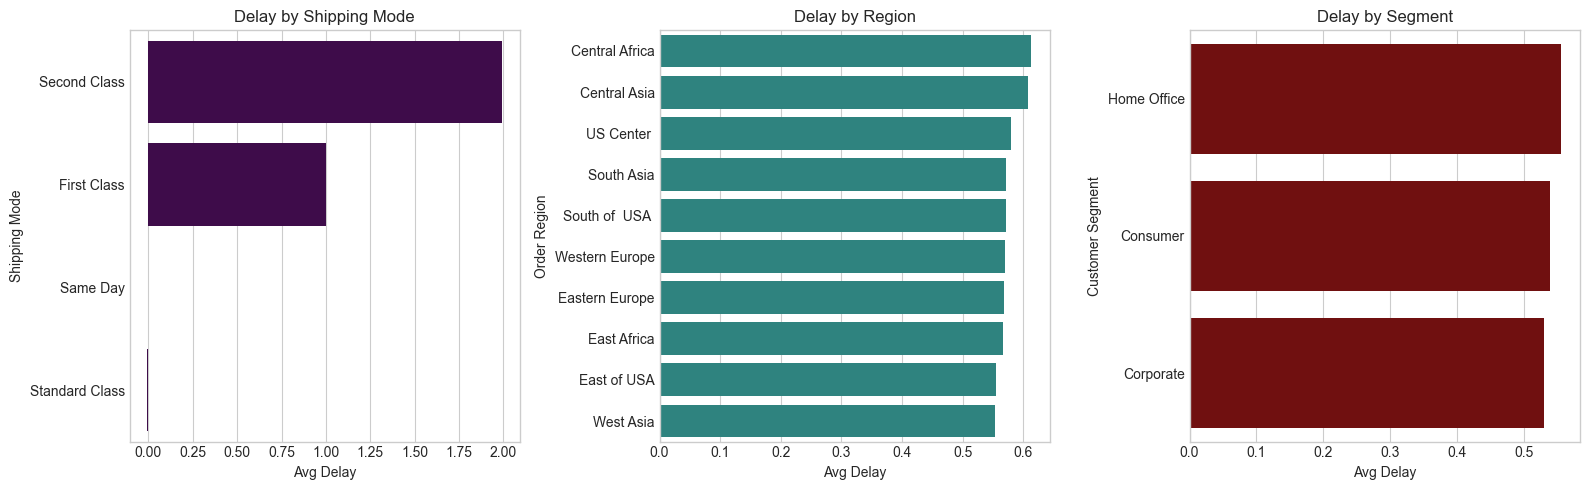

In [47]:
# Root Cause Analysis - identify factors contributing to delay

print("\n--- Root Cause Analysis ---\n")

# compute mean delay
shipping_delay = df.groupby('Shipping Mode')['Delay'].mean().sort_values(ascending=False)
region_delay = df.groupby('Order Region')['Delay'].mean().sort_values(ascending=False).head(10)
segment_delay = df.groupby('Customer Segment')['Delay'].mean().sort_values(ascending=False)

# print results
print("Delay by Shipping Mode:\n", shipping_delay)
print("\nDelay by Order Region:\n", region_delay)
print("\nDelay by Customer Segment:\n", segment_delay)


# visualization

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Shipping Mode
sns.barplot(x=shipping_delay.values, y=shipping_delay.index, color=primary_color, ax=axes[0])
axes[0].set_title("Delay by Shipping Mode")
axes[0].set_xlabel("Avg Delay")

# Region
sns.barplot(x=region_delay.values, y=region_delay.index, color=accent_color, ax=axes[1])
axes[1].set_title("Delay by Region")
axes[1].set_xlabel("Avg Delay")

# Customer Segment
sns.barplot(x=segment_delay.values, y=segment_delay.index, color=danger_color, ax=axes[2])
axes[2].set_title("Delay by Segment")
axes[2].set_xlabel("Avg Delay")

plt.tight_layout()
plt.show()

In [48]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,Product Price,shipping date (DateOrders),Shipping Mode,Order Processing Time,Delay,Is_Delayed,order_month,order_day,order_hour,Profitability Flag
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.750000,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22,Profit
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.750000,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12,Loss
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,327.750000,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12,Loss
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,327.750000,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11,Profit
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,...,327.750000,2018-01-15 11:24:00,Standard Class,2,-2,False,1,Saturday,11,Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,399.980011,Shipping on time,0,Fishing,EE. UU.,Home Office,Fan Shop,...,399.980011,2016-01-20 03:40:00,Standard Class,4,0,False,1,Saturday,3,Profit
180515,DEBIT,3,2,395.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,...,399.980011,2016-01-19 01:34:00,Second Class,3,1,True,1,Saturday,1,Loss
180516,TRANSFER,5,4,391.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,...,399.980011,2016-01-20 21:00:00,Standard Class,5,1,True,1,Friday,21,Profit
180517,PAYMENT,3,4,387.980011,Advance shipping,0,Fishing,Puerto Rico,Consumer,Fan Shop,...,399.980011,2016-01-18 20:18:00,Standard Class,3,-1,False,1,Friday,20,Profit



--- Time-Based Delay Analysis ---

Delay % by Month:
 order_month
Jan    54.254150
Feb    54.604550
Mar    54.809390
Apr    54.504230
May    54.998022
Jun    54.764535
Jul    53.731048
Aug    55.387128
Sep    55.388454
Oct    54.097044
Nov    54.860878
Dec    55.224003
Name: Is_Delayed, dtype: float64

Delay % by Day of Week:
 order_day
Monday       55.533838
Tuesday      53.984137
Wednesday    54.845175
Thursday     54.720188
Friday       54.488442
Saturday     54.261937
Sunday       55.152418
Name: Is_Delayed, dtype: float64

Delay % by Hour:
 order_hour
0     54.068641
1     55.422680
2     55.193735
3     54.142012
4     53.674683
5     55.267154
6     52.838802
7     54.988239
8     53.132903
9     54.357480
10    54.884668
11    53.374233
12    56.652661
13    55.867241
14    55.999441
15    55.591413
16    53.626220
17    54.839155
18    55.637018
19    51.884701
20    57.132896
21    54.238962
22    55.445545
23    54.798635
Name: Is_Delayed, dtype: float64


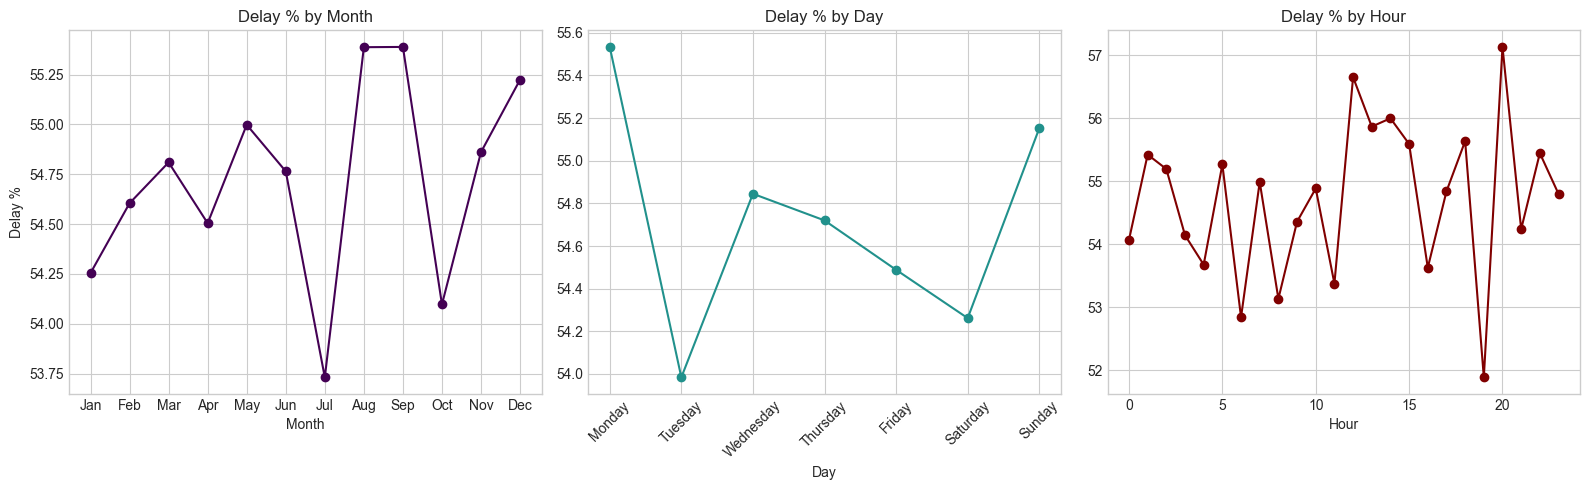

In [50]:
# Time-Based Analysis - Delay % by Month, Day, and Hour

print("\n--- Time-Based Delay Analysis ---\n")

# calculate delay % by month
month_delay = df.groupby('order_month')['Is_Delayed'].mean() * 100

# convert month number to name
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
month_delay.index = month_delay.index.map(month_map)

# calculate delay % by day of week
day_delay = df.groupby('order_day')['Is_Delayed'].mean() * 100

# fix correct day order
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_delay = day_delay.reindex(day_order)

# calculate delay % by hour
hour_delay = df.groupby('order_hour')['Is_Delayed'].mean() * 100

# print results
print("Delay % by Month:\n", month_delay)
print("\nDelay % by Day of Week:\n", day_delay)
print("\nDelay % by Hour:\n", hour_delay)

# visualization

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Month
axes[0].plot(month_delay.index, month_delay.values, marker='o', color=primary_color)
axes[0].set_title("Delay % by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Delay %")

# Day
axes[1].plot(day_delay.index, day_delay.values, marker='o', color=accent_color)
axes[1].set_title("Delay % by Day")
axes[1].set_xlabel("Day")
axes[1].tick_params(axis='x', rotation=45)

# Hour
axes[2].plot(hour_delay.index, hour_delay.values, marker='o', color=danger_color)
axes[2].set_title("Delay % by Hour")
axes[2].set_xlabel("Hour")

plt.tight_layout()
plt.show()

## Summary
- A large proportion of orders experience delivery delays.
- Delays are mainly driven by specific shipping modes, regions, and operational factors.
- Late deliveries negatively impact overall profitability.
- Time-based patterns indicate peak periods of higher delays.
- Improving logistics and planning can significantly enhance delivery performance.